In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor
import pickle

In [4]:
df=pd.read_csv('demand_forecasting.csv')

In [5]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='str')

In [6]:
features=[
    "Price",
    "Discount", 
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"

]

In [7]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [10]:
target='Demand'

In [8]:
X=df[features].copy()

In [11]:
y=df[target]

In [14]:
X.dtypes

Price                 float64
Discount                int64
Inventory Level         int64
Promotion               int64
Competitor Pricing    float64
Category                  str
dtype: object

In [12]:
label_encoder={}
categorical_cols=X.select_dtypes(include='object').columns

C:\Users\admin\AppData\Local\Temp\ipykernel_21608\1142767955.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=X.select_dtypes(include='object').columns


In [15]:
categorical_cols

Index(['Category'], dtype='str')

In [16]:
for col in categorical_cols:
    le=LabelEncoder()
    X[col]=le.fit_transform(X[col])
    label_encoder[col]=le


In [17]:
label_encoder

{'Category': LabelEncoder()}

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
xgb=XGBRegressor(objective='reg:squarederror',n_jobs=-1)

In [21]:
param_dict={
    'n_estimators':[200,300,500],
    'max_depth':[3,4,6,8],
    'learning_rate':[0.1,0.05,0.1],
    'subsample':[0.7,0.8,1.0],
    'colsample_bytree':[0.7,0.8,1.0],
    'min_child_weight':[1,3,5]
}


In [22]:
random_search=RandomizedSearchCV(estimator=xgb,param_distributions=param_dict,n_iter=25,scoring='neg_mean_squared_error',cv=3,verbose=1,random_state=42,n_jobs=-1)

In [24]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.1, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies 

In [25]:
random_search.best_params_

{'subsample': 0.7,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [26]:
best_model=random_search.best_estimator_

In [27]:
best_model.predict(X_test)

array([ 78.8287  ,  71.68242 ,  34.788765, ...,  73.23001 ,  62.261288,
       110.09047 ], shape=(15200,), dtype=float32)

In [30]:
y_pred=best_model.predict(X_test)

In [37]:
root_mean_squared_error(y_test, y_pred)

35.54729461669922

In [38]:
best_model.feature_importances_

array([0.07512447, 0.02245428, 0.02244147, 0.57829505, 0.02653709,
       0.27514762], dtype=float32)

In [39]:
features_importance=pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False) 

In [40]:
features_importance

Promotion             0.578295
Category              0.275148
Price                 0.075124
Competitor Pricing    0.026537
Discount              0.022454
Inventory Level       0.022441
dtype: float32

<Axes: title={'center': 'Feature Importance'}>

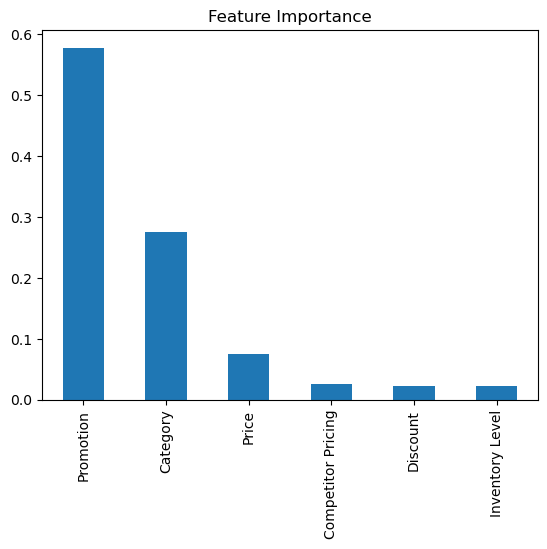

In [42]:
features_importance.plot(kind='bar',title='Feature Importance')

In [43]:
with open('label_encoder.pkl','wb') as f:
    pickle.dump(label_encoder,f)

In [44]:
with open('XGBRegressor_model.pkl','wb') as f:
    pickle.dump(best_model,f)